In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd 
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence


In [2]:
"""
Data loader for CatBoost V3.
This version:
1) de-extincts the flux using EBV
2) keeps all V2 features
3) adds 20 new high-value features:
   - negative flux fraction (4)
   - skew / kurtosis (6)
   - quantile ratios (6)
   - color features (4)
4) keeps the same overall format as V2 so it still works with later cells
"""

import os


from extinction import fitzpatrick99


class MallornDataLoader:
    """
    Loads MALLORN train/test metadata and lightcurves, then converts each object
    into a flat feature vector suitable for CatBoost.

    Expected structure:
    data/
        train_log.csv
        test_log.csv
        sample_submission.csv
        split_01/
            train_full_lightcurves.csv
            test_full_lightcurves.csv
        ...
        split_20/
            train_full_lightcurves.csv
            test_full_lightcurves.csv
    """

    FILTERS = ["u", "g", "r", "i", "z", "y"]

    # Effective wavelengths from the MALLORN notebook
    EFF_WL = {
        "u": 3641.0,
        "g": 4704.0,
        "r": 6155.0,
        "i": 7504.0,
        "z": 8695.0,
        "y": 10056.0,
    }

    # V2 features + 20 new V3 features
    FEATURE_COLUMNS = [
        # ---------------------------
        # Coverage / reliability (6)
        # ---------------------------
        "total_n_obs",
        "num_filters_seen",
        "global_time_span",
        "blue_n_obs",
        "red_n_obs",
        "coverage_balance",

        # ----------------------------------------
        # Core per-band brightness (18 = 6 bands x 3)
        # ----------------------------------------
        "u_flux_corr_median", "u_flux_corr_max", "u_snr_max",
        "g_flux_corr_median", "g_flux_corr_max", "g_snr_max",
        "r_flux_corr_median", "r_flux_corr_max", "r_snr_max",
        "i_flux_corr_median", "i_flux_corr_max", "i_snr_max",
        "z_flux_corr_median", "z_flux_corr_max", "z_snr_max",
        "y_flux_corr_median", "y_flux_corr_max", "y_snr_max",

        # -------------------
        # Color features (8) - original V2
        # -------------------
        "u_g",
        "g_r",
        "r_i",
        "i_z",
        "u_r_peak_ratio",
        "g_r_peak_ratio",
        "blue_red_ratio",
        "median_blue_red_ratio",

        # ---------------------------
        # Temporal shape features (10)
        # ---------------------------
        "global_peak_flux",
        "global_time_to_peak",
        "rise_slope",
        "decline_slope",
        "time_after_peak",
        "duration_above_halfmax",
        "duration_above_30pct_peak",
        "late_flux_over_peak",
        "last20pct_flux_over_peak",
        "peak_time_mjd",

        # ------------------------
        # AGN rejection features (6)
        # ------------------------
        "global_neg_flux_fraction",
        "global_sign_change_count",
        "median_abs_successive_diff",
        "fraction_negative_after_peak",
        "n_negative_points",
        "baseline_variability_ratio",

        # ==========================================
        # NEW V3 FEATURES (20 total)
        # ==========================================

        # ------------------------------------------
        # 1) Negative flux fraction features (4)
        # ------------------------------------------
        "u_neg_flux_fraction",
        "g_neg_flux_fraction",
        "r_neg_flux_fraction",
        "i_neg_flux_fraction",

        # ------------------------------------------
        # 2) Skew / kurtosis features (6)
        # ------------------------------------------
        "g_flux_skew",
        "r_flux_skew",
        "i_flux_skew",
        "g_flux_kurtosis",
        "r_flux_kurtosis",
        "i_flux_kurtosis",

        # ------------------------------------------
        # 3) Quantile ratio features (6)
        # ------------------------------------------
        "g_q90_q50_ratio",
        "r_q90_q50_ratio",
        "i_q90_q50_ratio",
        "g_max_median_ratio",
        "r_max_median_ratio",
        "i_max_median_ratio",

        # ------------------------------------------
        # 4) New color features (4)
        # ------------------------------------------
        "mean_g_r_color",
        "min_g_r_color",
        "mean_u_r_color",
        "min_u_r_color",
    ]

    def __init__(self, data_dir: str):
        self.data_dir = Path(data_dir)

        self.train_log_path = self.data_dir / "train_log.csv"
        self.test_log_path = self.data_dir / "test_log.csv"

        if not self.train_log_path.exists():
            raise FileNotFoundError(f"Missing file: {self.train_log_path}")
        if not self.test_log_path.exists():
            raise FileNotFoundError(f"Missing file: {self.test_log_path}")

        # Cache split lightcurve files so we do not reload the same CSV over and over
        self._lc_cache = {}

    def load_log(self, split_type: str = "train") -> pd.DataFrame:
        """
        split_type: 'train' or 'test'
        """
        if split_type == "train":
            return pd.read_csv(self.train_log_path)
        elif split_type == "test":
            return pd.read_csv(self.test_log_path)
        else:
            raise ValueError("split_type must be 'train' or 'test'")

    def _get_lightcurve_file(self, split_name: str, split_type: str) -> Path:
        """
        Example:
            split_name = 'split_01'
            split_type = 'train'
        returns:
            data/split_01/train_full_lightcurves.csv
        """
        filename = f"{split_type}_full_lightcurves.csv"
        path = self.data_dir / split_name / filename

        if not path.exists():
            raise FileNotFoundError(f"Missing lightcurve file: {path}")

        return path

    def _load_split_lightcurves(self, split_name: str, split_type: str) -> pd.DataFrame:
        """
        Loads one split lightcurve CSV into memory and caches it.
        """
        cache_key = (split_name, split_type)

        if cache_key not in self._lc_cache:
            path = self._get_lightcurve_file(split_name, split_type)
            df = pd.read_csv(path)
            self._lc_cache[cache_key] = df

        return self._lc_cache[cache_key]

    def get_object_lightcurve(self, object_id: str, split_name: str, split_type: str = "train") -> pd.DataFrame:
        """
        Returns all rows in the relevant split lightcurve file for one object.
        """
        df = self._load_split_lightcurves(split_name, split_type)
        obj_df = df[df["object_id"] == object_id].copy()

        if obj_df.empty:
            print(f"Warning: no lightcurve rows found for object_id={object_id} in {split_name}/{split_type}")

        return obj_df

    @staticmethod
    def _safe_slope(x: np.ndarray, y: np.ndarray) -> float:
        """
        Linear slope of y vs x. Returns NaN if not enough points.
        """
        if len(x) < 2 or len(y) < 2:
            return np.nan
        if np.allclose(x, x[0]):
            return 0.0

        try:
            slope = np.polyfit(x, y, 1)[0]
            return float(slope)
        except Exception:
            return np.nan

    @staticmethod
    def _safe_median(arr: np.ndarray) -> float:
        if len(arr) == 0:
            return np.nan
        return float(np.median(arr))

    @staticmethod
    def _safe_max(arr: np.ndarray) -> float:
        if len(arr) == 0:
            return np.nan
        return float(np.max(arr))

    @staticmethod
    def _safe_quantile(arr: np.ndarray, q: float) -> float:
        if len(arr) == 0:
            return np.nan
        return float(np.quantile(arr, q))

    @staticmethod
    def _safe_ratio(num: float, den: float, eps: float = 1e-8) -> float:
        """
        Safe ratio for features.
        Returns NaN if either side is NaN.
        """
        if pd.isna(num) or pd.isna(den):
            return np.nan
        return float(num / (den + eps))

    @staticmethod
    def _count_sign_changes(arr: np.ndarray) -> int:
        """
        Count sign changes after removing exact zeros.
        """
        if len(arr) < 2:
            return 0

        sign_arr = np.sign(arr)
        sign_arr = sign_arr[sign_arr != 0]

        if len(sign_arr) < 2:
            return 0

        return int(np.sum(sign_arr[1:] != sign_arr[:-1]))

    @staticmethod
    def _safe_skew(arr: np.ndarray) -> float:
        """
        Sample skewness-like statistic.
        Returns NaN if too few points or zero variance.
        """
        arr = np.asarray(arr, dtype=float)
        arr = arr[~np.isnan(arr)]

        if len(arr) < 3:
            return np.nan

        mean = np.mean(arr)
        std = np.std(arr, ddof=1)

        if std < 1e-12:
            return 0.0

        z = (arr - mean) / std
        return float(np.mean(z ** 3))

    @staticmethod
    def _safe_kurtosis(arr: np.ndarray) -> float:
        """
        Excess kurtosis-like statistic.
        Returns NaN if too few points or zero variance.
        """
        arr = np.asarray(arr, dtype=float)
        arr = arr[~np.isnan(arr)]

        if len(arr) < 4:
            return np.nan

        mean = np.mean(arr)
        std = np.std(arr, ddof=1)

        if std < 1e-12:
            return 0.0

        z = (arr - mean) / std
        return float(np.mean(z ** 4) - 3.0)

    @staticmethod
    def _safe_interp(x_src: np.ndarray, y_src: np.ndarray, x_tgt: np.ndarray) -> np.ndarray:
        """
        Linear interpolation over overlapping domain only.
        Caller should ensure enough source points.
        """
        if len(x_src) < 2:
            return np.array([], dtype=float)

        x_min = np.min(x_src)
        x_max = np.max(x_src)
        mask = (x_tgt >= x_min) & (x_tgt <= x_max)

        if not np.any(mask):
            return np.array([], dtype=float)

        x_valid = x_tgt[mask]
        y_interp = np.interp(x_valid, x_src, y_src)
        return x_valid, y_interp

    @staticmethod
    def _empty_feature_dict():
        return {col: np.nan for col in MallornDataLoader.FEATURE_COLUMNS}

    def _apply_extinction_correction(self, flux: np.ndarray, flux_err: np.ndarray, band: str, ebv: float):
        """
        De-extinct flux and flux_err using the MALLORN notebook method:
            A_lambda = fitzpatrick99(eff_wl, ebv * 3.1)
            flux_corr = flux * 10^(A_lambda / 2.5)

        We apply the same multiplicative factor to flux_err.
        """
        if pd.isna(ebv):
            return flux.copy(), flux_err.copy()

        eff_wl = np.array([self.EFF_WL[band]], dtype=float)
        A_lambda = fitzpatrick99(eff_wl, ebv * 3.1)[0]
        scale = 10 ** (A_lambda / 2.5)

        flux_corr = flux * scale
        flux_err_corr = flux_err * scale

        return flux_corr, flux_err_corr

    def _compute_pair_color_stats(self, band_data: dict, band_a: str, band_b: str):
        """
        Computes mean/min color = flux_a - flux_b by interpolating band_b
        onto the timestamps of band_a over the overlapping time region.
        """
        if band_data.get(band_a) is None or band_data.get(band_b) is None:
            return np.nan, np.nan

        a = band_data[band_a]
        b = band_data[band_b]

        if len(a["t"]) < 2 or len(b["t"]) < 2:
            return np.nan, np.nan

        try:
            x_valid, b_interp = self._safe_interp(b["t"], b["f_corr"], a["t"])
            if len(x_valid) == 0:
                return np.nan, np.nan

            # grab matching a flux values at the same timestamps used above
            a_mask = (a["t"] >= np.min(x_valid)) & (a["t"] <= np.max(x_valid))
            a_times = a["t"][a_mask]
            a_flux = a["f_corr"][a_mask]

            # ensure lengths line up after overlap trimming
            common_len = min(len(a_flux), len(b_interp))
            if common_len == 0:
                return np.nan, np.nan

            color = a_flux[:common_len] - b_interp[:common_len]

            if len(color) == 0:
                return np.nan, np.nan

            return float(np.mean(color)), float(np.min(color))

        except Exception:
            return np.nan, np.nan

    def extract_lightcurve_features(self, lc_df: pd.DataFrame, ebv: float = np.nan) -> dict:
        """
        Converts one object's variable-length lightcurve into V3 lightcurve features.

        IMPORTANT:
        Metadata features like Z, Z_err, EBV already come from the log file.
        """
        features = self._empty_feature_dict()

        if lc_df.empty:
            # Coverage features become 0 where appropriate
            features["total_n_obs"] = 0
            features["num_filters_seen"] = 0
            features["blue_n_obs"] = 0
            features["red_n_obs"] = 0
            features["coverage_balance"] = 0.0
            features["n_negative_points"] = 0
            features["global_sign_change_count"] = 0

            # new V3 negatives
            for col in ["u_neg_flux_fraction", "g_neg_flux_fraction", "r_neg_flux_fraction", "i_neg_flux_fraction"]:
                features[col] = 0.0

            return features

        lc_df = lc_df.copy().sort_values("Time (MJD)").reset_index(drop=True)

        # Store corrected band-level data
        band_data = {}
        band_counts = {}

        for band in self.FILTERS:
            band_df = lc_df[lc_df["Filter"] == band].copy().sort_values("Time (MJD)")
            band_counts[band] = int(len(band_df))

            if band_df.empty:
                band_data[band] = None
                continue

            t = band_df["Time (MJD)"].to_numpy(dtype=float)
            f = band_df["Flux"].to_numpy(dtype=float)
            ferr = band_df["Flux_err"].to_numpy(dtype=float)

            f_corr, ferr_corr = self._apply_extinction_correction(f, ferr, band, ebv)

            snr = np.divide(
                np.abs(f_corr),
                ferr_corr,
                out=np.full_like(f_corr, np.nan, dtype=float),
                where=(ferr_corr > 0)
            )

            band_data[band] = {
                "t": t,
                "f_corr": f_corr,
                "ferr_corr": ferr_corr,
                "snr": snr
            }

            # Core per-band brightness features
            features[f"{band}_flux_corr_median"] = self._safe_median(f_corr)
            features[f"{band}_flux_corr_max"] = self._safe_max(f_corr)
            features[f"{band}_snr_max"] = float(np.nanmax(snr)) if np.any(~np.isnan(snr)) else np.nan

        # ---------------------------
        # Coverage / reliability (6)
        # ---------------------------
        features["total_n_obs"] = int(len(lc_df))
        features["num_filters_seen"] = int(lc_df["Filter"].nunique())

        all_t_raw = lc_df["Time (MJD)"].to_numpy(dtype=float)
        features["global_time_span"] = float(np.max(all_t_raw) - np.min(all_t_raw)) if len(all_t_raw) > 1 else 0.0

        blue_n_obs = band_counts["u"] + band_counts["g"]
        red_n_obs = band_counts["r"] + band_counts["i"] + band_counts["z"] + band_counts["y"]

        features["blue_n_obs"] = int(blue_n_obs)
        features["red_n_obs"] = int(red_n_obs)
        features["coverage_balance"] = float(blue_n_obs / (red_n_obs + 1e-8))

        # -------------------
        # Color features (8) - original V2
        # -------------------
        u_med = features["u_flux_corr_median"]
        g_med = features["g_flux_corr_median"]
        r_med = features["r_flux_corr_median"]
        i_med = features["i_flux_corr_median"]
        z_med = features["z_flux_corr_median"]

        u_max = features["u_flux_corr_max"]
        g_max = features["g_flux_corr_max"]
        r_max = features["r_flux_corr_max"]

        features["u_g"] = u_med - g_med if not (pd.isna(u_med) or pd.isna(g_med)) else np.nan
        features["g_r"] = g_med - r_med if not (pd.isna(g_med) or pd.isna(r_med)) else np.nan
        features["r_i"] = r_med - i_med if not (pd.isna(r_med) or pd.isna(i_med)) else np.nan
        features["i_z"] = i_med - z_med if not (pd.isna(i_med) or pd.isna(z_med)) else np.nan

        features["u_r_peak_ratio"] = self._safe_ratio(u_max, r_max)
        features["g_r_peak_ratio"] = self._safe_ratio(g_max, r_max)

        blue_med_sum = 0.0
        red_med_sum = 0.0
        blue_valid = True
        red_valid = True

        if pd.isna(u_med) or pd.isna(g_med):
            blue_valid = False
        else:
            blue_med_sum = u_med + g_med

        red_meds = [features["r_flux_corr_median"], features["i_flux_corr_median"]]
        if any(pd.isna(v) for v in red_meds):
            red_valid = False
        else:
            red_med_sum = sum(red_meds)

        features["blue_red_ratio"] = self._safe_ratio(blue_med_sum, red_med_sum) if (blue_valid and red_valid) else np.nan

        all_band_medians = [features[f"{b}_flux_corr_median"] for b in self.FILTERS]
        valid_medians = [v for v in all_band_medians if not pd.isna(v)]

        if len(valid_medians) >= 4 and not pd.isna(u_med) and not pd.isna(g_med):
            median_blue = (u_med + g_med) / 2.0
            median_red = float(np.median(valid_medians))
            features["median_blue_red_ratio"] = self._safe_ratio(median_blue, median_red)
        else:
            features["median_blue_red_ratio"] = np.nan

        # ------------------------------------------------
        # Build global corrected lightcurve across all bands
        # ------------------------------------------------
        corrected_frames = []

        for band in self.FILTERS:
            if band_data[band] is None:
                continue

            bd = band_data[band]
            tmp = pd.DataFrame({
                "Time (MJD)": bd["t"],
                "Filter": band,
                "Flux_corr": bd["f_corr"],
                "Flux_err_corr": bd["ferr_corr"]
            })
            corrected_frames.append(tmp)

        if len(corrected_frames) == 0:
            return features

        all_corr_df = pd.concat(corrected_frames, axis=0).sort_values("Time (MJD)").reset_index(drop=True)

        t_all = all_corr_df["Time (MJD)"].to_numpy(dtype=float)
        f_all = all_corr_df["Flux_corr"].to_numpy(dtype=float)

        # ---------------------------
        # Temporal shape features (10)
        # ---------------------------
        peak_idx = int(np.argmax(f_all))
        peak_flux = float(f_all[peak_idx])
        peak_time_mjd = float(t_all[peak_idx])

        features["global_peak_flux"] = peak_flux
        features["peak_time_mjd"] = peak_time_mjd
        features["global_time_to_peak"] = float(peak_time_mjd - np.min(t_all))

        pre_mask = t_all <= peak_time_mjd
        post_mask = t_all >= peak_time_mjd

        t_pre = t_all[pre_mask]
        f_pre = f_all[pre_mask]
        t_post = t_all[post_mask]
        f_post = f_all[post_mask]

        features["rise_slope"] = self._safe_slope(t_pre, f_pre)
        features["decline_slope"] = self._safe_slope(t_post, f_post)

        features["time_after_peak"] = float(np.max(t_all) - peak_time_mjd)

        if peak_flux > 0:
            half_thresh = 0.5 * peak_flux
            low_thresh = 0.3 * peak_flux

            t_half = t_all[f_all >= half_thresh]
            t_low = t_all[f_all >= low_thresh]

            features["duration_above_halfmax"] = float(np.max(t_half) - np.min(t_half)) if len(t_half) >= 2 else 0.0
            features["duration_above_30pct_peak"] = float(np.max(t_low) - np.min(t_low)) if len(t_low) >= 2 else 0.0
        else:
            features["duration_above_halfmax"] = np.nan
            features["duration_above_30pct_peak"] = np.nan

        if peak_flux != 0:
            late_mask = t_all >= (np.min(t_all) + 0.8 * (np.max(t_all) - np.min(t_all)))
            late_vals = f_all[late_mask]

            features["late_flux_over_peak"] = (
                float(np.median(late_vals) / peak_flux)
                if len(late_vals) > 0 else np.nan
            )

            features["last20pct_flux_over_peak"] = (
                float(np.mean(late_vals) / peak_flux)
                if len(late_vals) > 0 else np.nan
            )
        else:
            features["late_flux_over_peak"] = np.nan
            features["last20pct_flux_over_peak"] = np.nan

        # ------------------------
        # AGN rejection features (6)
        # ------------------------
        n_negative = int(np.sum(f_all < 0))
        features["n_negative_points"] = n_negative
        features["global_neg_flux_fraction"] = float(n_negative / len(f_all)) if len(f_all) > 0 else np.nan

        features["global_sign_change_count"] = self._count_sign_changes(f_all)

        if len(f_all) >= 2:
            successive_diff = np.diff(f_all)
            features["median_abs_successive_diff"] = float(np.median(np.abs(successive_diff)))
        else:
            features["median_abs_successive_diff"] = np.nan

        post_peak_flux = f_all[t_all > peak_time_mjd]
        if len(post_peak_flux) > 0:
            features["fraction_negative_after_peak"] = float(np.mean(post_peak_flux < 0))
        else:
            features["fraction_negative_after_peak"] = np.nan

        pre_peak_flux = f_all[t_all < peak_time_mjd]
        if len(pre_peak_flux) >= 2 and np.abs(peak_flux) > 1e-8:
            features["baseline_variability_ratio"] = float(np.std(pre_peak_flux, ddof=1) / (np.abs(peak_flux) + 1e-8))
        else:
            features["baseline_variability_ratio"] = np.nan

        # ==================================================
        # NEW V3 FEATURES
        # ==================================================

        # ------------------------------------------
        # 1) Negative flux fraction features (4)
        # ------------------------------------------
        for band in ["u", "g", "r", "i"]:
            if band_data[band] is None:
                features[f"{band}_neg_flux_fraction"] = np.nan
            else:
                arr = band_data[band]["f_corr"]
                features[f"{band}_neg_flux_fraction"] = float(np.mean(arr < 0)) if len(arr) > 0 else np.nan

        # ------------------------------------------
        # 2) Skew / kurtosis features (6)
        # ------------------------------------------
        for band in ["g", "r", "i"]:
            if band_data[band] is None:
                features[f"{band}_flux_skew"] = np.nan
                features[f"{band}_flux_kurtosis"] = np.nan
            else:
                arr = band_data[band]["f_corr"]
                features[f"{band}_flux_skew"] = self._safe_skew(arr)
                features[f"{band}_flux_kurtosis"] = self._safe_kurtosis(arr)

        # ------------------------------------------
        # 3) Quantile ratio features (6)
        # ------------------------------------------
        for band in ["g", "r", "i"]:
            if band_data[band] is None:
                features[f"{band}_q90_q50_ratio"] = np.nan
                features[f"{band}_max_median_ratio"] = np.nan
            else:
                arr = band_data[band]["f_corr"]
                q90 = self._safe_quantile(arr, 0.90)
                q50 = self._safe_quantile(arr, 0.50)
                maxv = self._safe_max(arr)
                medv = self._safe_median(arr)

                features[f"{band}_q90_q50_ratio"] = self._safe_ratio(q90, q50)
                features[f"{band}_max_median_ratio"] = self._safe_ratio(maxv, medv)

        # ------------------------------------------
        # 4) New color features (4)
        # ------------------------------------------
        mean_gr, min_gr = self._compute_pair_color_stats(band_data, "g", "r")
        mean_ur, min_ur = self._compute_pair_color_stats(band_data, "u", "r")

        features["mean_g_r_color"] = mean_gr
        features["min_g_r_color"] = min_gr
        features["mean_u_r_color"] = mean_ur
        features["min_u_r_color"] = min_ur

        return features

    def build_feature_table(self, split_type: str = "train", max_objects: int = None) -> pd.DataFrame:
        """
        Builds one flat row per object:
            metadata columns + extracted lightcurve features

        max_objects can be used for debugging on a small subset.
        """
        log_df = self.load_log(split_type=split_type).copy()

        if max_objects is not None:
            log_df = log_df.iloc[:max_objects].copy()

        rows = []

        for idx, row in log_df.iterrows():
            object_id = row["object_id"]
            split_name = row["split"]
            ebv = row.get("EBV", np.nan)

            lc_df = self.get_object_lightcurve(
                object_id=object_id,
                split_name=split_name,
                split_type=split_type
            )

            lc_features = self.extract_lightcurve_features(lc_df, ebv=ebv)

            combined = row.to_dict()
            combined.update(lc_features)
            rows.append(combined)

            if (idx + 1) % 500 == 0:
                print(f"Processed {idx + 1} objects...")

        feature_df = pd.DataFrame(rows)

        # Optional sanity check
        expected_cols = set(self.FEATURE_COLUMNS)
        missing = expected_cols - set(feature_df.columns)
        if missing:
            raise ValueError(f"Missing expected V3 feature columns: {missing}")

        return feature_df

In [3]:
loader = MallornDataLoader("data")

train_features = loader.build_feature_table(split_type="train")
test_features = loader.build_feature_table(split_type="test")

print(train_features.shape)
print(test_features.shape)

train_features.to_csv("train_features_v2.csv", index=False)
test_features.to_csv("test_features_v2.csv", index=False)

Processed 500 objects...
Processed 1000 objects...
Processed 1500 objects...
Processed 2000 objects...
Processed 2500 objects...
Processed 3000 objects...
Processed 500 objects...
Processed 1000 objects...
Processed 1500 objects...
Processed 2000 objects...
Processed 2500 objects...
Processed 3000 objects...
Processed 3500 objects...
Processed 4000 objects...
Processed 4500 objects...
Processed 5000 objects...
Processed 5500 objects...
Processed 6000 objects...
Processed 6500 objects...
Processed 7000 objects...
(3043, 76)
(7135, 75)


In [4]:
'''
 Drop the columns that are not needed here. Play around with this stuff to only use the data we want

 '''

drop_cols = ["object_id", "English Translation", "SpecType", "split", "target"]
feature_cols = [c for c in train_features.columns if c not in drop_cols]

X = train_features[feature_cols]
y = train_features["target"]
X_test = test_features[[c for c in feature_cols if c in test_features.columns]]

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
import pandas as pd

'''
This cell holds the CatBoost model, as well as the training loop.
The training loop utilizes cross-fold validation.
Also stores validation F1-vs-iteration curves for plotting later.

IMPORTANT:
- eval_metric uses unweighted F1 (matches Kaggle and mean_f1)
- Curve extraction is robust to metric naming changes
- Also stores fold validation predictions for confusion matrix
'''

# Cross Validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []
curve_results = []

class_weight_options = [8.5, 9]
depth_options = [6]
lr_options = [0.025, 0.03]
l2_options = [5, 7]
threshold_options = [0.5]

run_name = "cv_run_01"   # change this each time you do a new experiment

for cw in class_weight_options:
    for depth in depth_options:
        for lr in lr_options:
            for l2 in l2_options:
                for threshold in threshold_options:

                    fold_f1s = []
                    fold_precisions = []
                    fold_recalls = []
                    fold_best_iters = []
                    fold_val_f1_curves = []

                    # NEW: store out-of-fold validation predictions
                    fold_true_labels = []
                    fold_pred_labels = []
                    fold_pred_probs = []

                    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):

                        X_train = X.iloc[train_idx]
                        X_val   = X.iloc[val_idx]
                        y_train = y.iloc[train_idx]
                        y_val   = y.iloc[val_idx]

                        model = CatBoostClassifier(
                            iterations=700,
                            learning_rate=lr,
                            depth=depth,
                            class_weights=[1, cw],
                            l2_leaf_reg=l2,
                            eval_metric="F1:use_weights=false",
                            loss_function="Logloss",
                            subsample=0.8,
                            colsample_bylevel=0.8,
                            random_seed=42,
                            verbose=False
                        )

                        model.fit(
                            X_train, y_train,
                            eval_set=(X_val, y_val),
                            use_best_model=True,
                            early_stopping_rounds=125
                        )

                        # -----------------------------
                        # Standard evaluation (matches Kaggle)
                        # -----------------------------
                        val_probs = model.predict_proba(X_val)[:, 1]
                        val_preds = (val_probs >= threshold).astype(int)

                        f1 = f1_score(y_val, val_preds, zero_division=0)
                        precision = precision_score(y_val, val_preds, zero_division=0)
                        recall = recall_score(y_val, val_preds, zero_division=0)

                        fold_f1s.append(f1)
                        fold_precisions.append(precision)
                        fold_recalls.append(recall)
                        fold_best_iters.append(model.get_best_iteration())

                        # NEW: save fold validation labels/preds/probs
                        fold_true_labels.append(y_val.to_numpy())
                        fold_pred_labels.append(val_preds)
                        fold_pred_probs.append(val_probs)

                        # -----------------------------
                        # Store per-iteration validation F1 curve
                        # -----------------------------
                        evals_result = model.get_evals_result()

                        val_key = (
                            "validation"
                            if "validation" in evals_result
                            else "validation_0"
                        )

                        metric_key = [
                            k for k in evals_result[val_key].keys()
                            if "F1" in k
                        ][0]

                        val_f1_curve = evals_result[val_key][metric_key]
                        fold_val_f1_curves.append(val_f1_curve)

                    # -----------------------------
                    # Store summary metrics
                    # -----------------------------
                    results.append({
                        "run_name": run_name,
                        "class_weight_1": cw,
                        "depth": depth,
                        "learning_rate": lr,
                        "l2_leaf_reg": l2,
                        "threshold": threshold,

                        "fold_1_f1": fold_f1s[0],
                        "fold_2_f1": fold_f1s[1],
                        "fold_3_f1": fold_f1s[2],
                        "fold_4_f1": fold_f1s[3],
                        "fold_5_f1": fold_f1s[4],

                        "mean_precision": np.mean(fold_precisions),
                        "mean_recall": np.mean(fold_recalls),
                        "mean_f1": np.mean(fold_f1s),
                        "std_f1": np.std(fold_f1s),
                        "mean_best_iteration": np.mean(fold_best_iters),
                    })

                    # -----------------------------
                    # Store curves + validation predictions
                    # -----------------------------
                    curve_results.append({
                        "run_name": run_name,
                        "class_weight_1": cw,
                        "depth": depth,
                        "learning_rate": lr,
                        "l2_leaf_reg": l2,
                        "threshold": threshold,
                        "fold_val_f1_curves": fold_val_f1_curves,

                        # NEW
                        "fold_true_labels": fold_true_labels,
                        "fold_pred_labels": fold_pred_labels,
                        "fold_pred_probs": fold_pred_probs
                    })

results_df = pd.DataFrame(results)
results_df = (
    results_df
    .sort_values("mean_f1", ascending=False)
    .reset_index(drop=True)
)

print(results_df.head(20))

    run_name  class_weight_1  depth  learning_rate  l2_leaf_reg  threshold  \
0  cv_run_01             8.5      6          0.030            5        0.5   
1  cv_run_01             9.0      6          0.025            7        0.5   
2  cv_run_01             9.0      6          0.025            5        0.5   
3  cv_run_01             9.0      6          0.030            7        0.5   
4  cv_run_01             9.0      6          0.030            5        0.5   
5  cv_run_01             8.5      6          0.030            7        0.5   
6  cv_run_01             8.5      6          0.025            5        0.5   
7  cv_run_01             8.5      6          0.025            7        0.5   

   fold_1_f1  fold_2_f1  fold_3_f1  fold_4_f1  fold_5_f1   mean_f1    std_f1  \
0   0.465753   0.588235   0.518519   0.638889   0.612903  0.564860  0.063725   
1   0.465753   0.571429   0.493151   0.648649   0.644068  0.564610  0.075235   
2   0.435897   0.588235   0.473684   0.638889   0.655172 

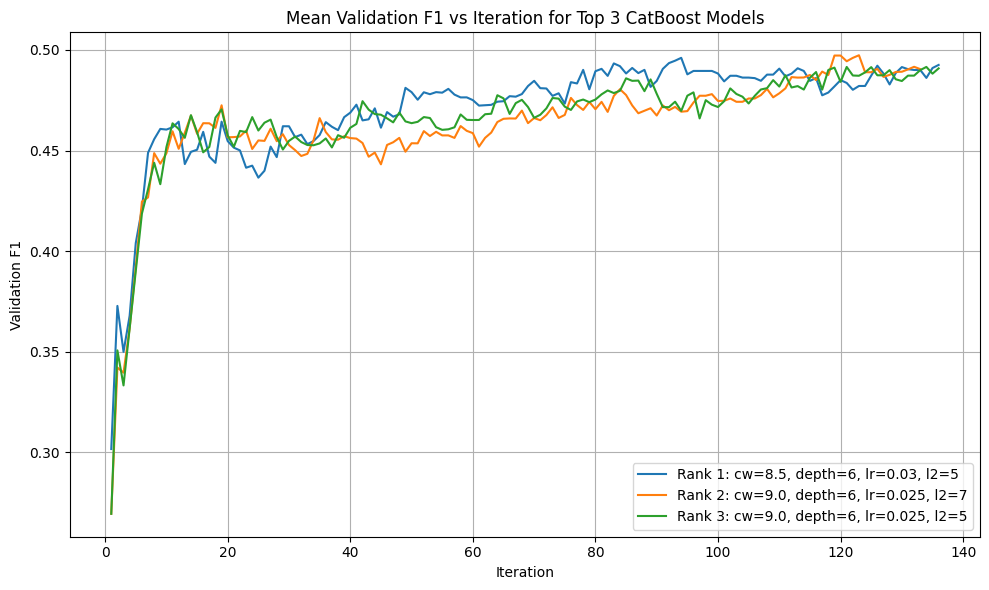

In [6]:


'''
Plot mean validation F1 vs iteration for the top 3 models
'''

# Sort results again just to be safe
results_df = results_df.sort_values("mean_f1", ascending=False).reset_index(drop=True)

# Grab top 3 models
top3_models = results_df.head(3)

plt.figure(figsize=(10, 6))

for i, row in top3_models.iterrows():
    cw = row["class_weight_1"]
    depth = row["depth"]
    lr = row["learning_rate"]
    l2 = row["l2_leaf_reg"]
    threshold = row["threshold"]

    # Find matching curve entry
    matching_curve_entry = None
    for entry in curve_results:
        if (
            entry["class_weight_1"] == cw and
            entry["depth"] == depth and
            entry["learning_rate"] == lr and
            entry["l2_leaf_reg"] == l2 and
            entry["threshold"] == threshold
        ):
            matching_curve_entry = entry
            break

    if matching_curve_entry is None:
        print(f"Could not find curve data for model rank {i+1}")
        continue

    fold_curves = matching_curve_entry["fold_val_f1_curves"]

    # Early stopping makes curve lengths different, so trim to shortest fold
    min_len = min(len(curve) for curve in fold_curves)
    trimmed_curves = np.array([curve[:min_len] for curve in fold_curves])

    mean_curve = trimmed_curves.mean(axis=0)

    iterations = np.arange(1, min_len + 1)

    label = (
        f"Rank {i+1}: cw={cw}, depth={depth}, "
        f"lr={lr}, l2={l2}"
    )

    plt.plot(iterations, mean_curve, label=label)

plt.xlabel("Iteration")
plt.ylabel("Validation F1")
plt.title("Mean Validation F1 vs Iteration for Top 3 CatBoost Models")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Best model parameters:
class_weight_1 = 8.5
depth          = 6
learning_rate  = 0.03
l2_leaf_reg    = 5
threshold      = 0.5

Combined 5-Fold CV Validation Metrics:
Precision: 0.5366
Recall:    0.5946
F1 Score:  0.5641

Confusion Matrix Counts:
TN = 2819
FP = 76
FN = 60
TP = 88


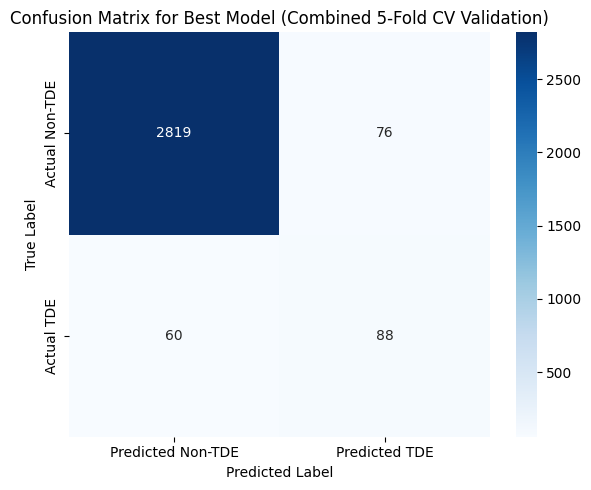

In [8]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns


'''
Confusion matrix for the best-ranked model
using combined 5-fold CV validation predictions
'''

# Best model from results table
best_row = results_df.iloc[0]

cw = best_row["class_weight_1"]
depth = best_row["depth"]
lr = best_row["learning_rate"]
l2 = best_row["l2_leaf_reg"]
threshold = best_row["threshold"]

# Find matching saved entry
matching_entry = None
for entry in curve_results:
    if (
        entry["class_weight_1"] == cw and
        entry["depth"] == depth and
        entry["learning_rate"] == lr and
        entry["l2_leaf_reg"] == l2 and
        entry["threshold"] == threshold
    ):
        matching_entry = entry
        break

if matching_entry is None:
    raise ValueError("Could not find stored validation predictions for best model.")

# Combine all 5 validation folds
y_true_all = np.concatenate(matching_entry["fold_true_labels"])
y_pred_all = np.concatenate(matching_entry["fold_pred_labels"])

# Metrics
cm = confusion_matrix(y_true_all, y_pred_all)
precision = precision_score(y_true_all, y_pred_all, zero_division=0)
recall = recall_score(y_true_all, y_pred_all, zero_division=0)
f1 = f1_score(y_true_all, y_pred_all, zero_division=0)

tn, fp, fn, tp = cm.ravel()

print("Best model parameters:")
print(f"class_weight_1 = {cw}")
print(f"depth          = {depth}")
print(f"learning_rate  = {lr}")
print(f"l2_leaf_reg    = {l2}")
print(f"threshold      = {threshold}")

print("\nCombined 5-Fold CV Validation Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nConfusion Matrix Counts:")
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Non-TDE", "Predicted TDE"],
    yticklabels=["Actual Non-TDE", "Actual TDE"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Best Model (Combined 5-Fold CV Validation)")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

'''
Plot cross-validation F1 for best model
'''

best_row = results_df.iloc[0]

fold_scores = [
    best_row["fold_1_f1"],
    best_row["fold_2_f1"],
    best_row["fold_3_f1"],
    best_row["fold_4_f1"],
    best_row["fold_5_f1"],
]

fold_labels = ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"]

plt.figure(figsize=(8, 5))

plt.bar(fold_labels, fold_scores)

plt.axhline(
    best_row["mean_f1"],
    linestyle="--",
    label=f"Mean F1 = {best_row['mean_f1']:.3f}"
)

plt.ylabel("F1 Score")
plt.title("Cross-Validation F1 Scores by Fold")
plt.legend()

plt.grid(axis="y")
plt.tight_layout()
plt.show()

KeyError: 'fold_1_f1'

In [ ]:
'''
Append the top 5 models to catboost_results.csv
without overwriting existing data
'''

import os

# Select top 5 rows
top5_df = results_df.head(5).copy()

# Add rank column
top5_df.insert(0, "rank", range(1, len(top5_df) + 1))

# Rename columns to match your format
top5_df = top5_df.rename(columns={
    "mean_precision": "Precision",
    "mean_recall": "Recall",
    "mean_f1": "f1"
})

# Reorder columns
top5_df = top5_df[
    [
        "rank",
        "class_weight_1",
        "depth",
        "learning_rate",
        "l2_leaf_reg",
        "threshold",
        "Precision",
        "Recall",
        "f1"
    ]
]

filename = "catboost_results.csv"

# Check if file exists
file_exists = os.path.isfile(filename)

# Append without overwriting
top5_df.to_csv(
    filename,
    mode="a",                 # append
    header=not file_exists,   # only write header if file doesn't exist
    index=False
)

print(f"Top 5 models appended to '{filename}'")
print(top5_df)

Top 5 models appended to 'catboost_results.csv'
   rank  class_weight_1  depth  learning_rate  l2_leaf_reg  threshold  \
0     1             9.0      5          0.025            7        0.5   
1     2             8.5      5          0.030            5        0.5   
2     3             9.0      6          0.020            7        0.5   
3     4             9.0      5          0.020            5        0.5   
4     5             8.5      6          0.030            7        0.5   

   Precision    Recall        f1  
0   0.450114  0.664138  0.526825  
1   0.436465  0.664138  0.523960  
2   0.412820  0.691034  0.513961  
3   0.416003  0.670575  0.511532  
4   0.408041  0.697701  0.508873  


In [10]:
'''Get the best model. Save the paramters and train it on ALL the training data. Then we will use it to test'''
# Get best parameters
best_row = results_df.iloc[0]
print(best_row)

# Get best parameters
best_row = results_df.iloc[0]

best_cw = best_row["class_weight_1"]
best_depth = best_row["depth"]
best_lr = best_row["learning_rate"]
best_l2 = best_row["l2_leaf_reg"]
best_threshold = best_row["threshold"]

print("Best parameters:")
print(best_row)

# Train the final model
final_model = CatBoostClassifier(
    iterations=int(best_row["mean_best_iteration"]),
    learning_rate=best_lr,
    depth=best_depth,
    class_weights=[1, best_cw],
    l2_leaf_reg=best_l2,
    eval_metric="F1",
    subsample = 0.8,
    colsample_bylevel = 0.8,
    random_seed=42,
    verbose=100
)

final_model.fit(X,y)

run_name               cv_run_01
class_weight_1               8.5
depth                          6
learning_rate               0.03
l2_leaf_reg                    5
threshold                    0.5
fold_1_f1               0.465753
fold_2_f1               0.588235
fold_3_f1               0.518519
fold_4_f1               0.638889
fold_5_f1               0.612903
mean_f1                  0.56486
std_f1                  0.063725
mean_best_iteration        192.4
Name: 0, dtype: object
Best parameters:
run_name               cv_run_01
class_weight_1               8.5
depth                          6
learning_rate               0.03
l2_leaf_reg                    5
threshold                    0.5
fold_1_f1               0.465753
fold_2_f1               0.588235
fold_3_f1               0.518519
fold_4_f1               0.638889
fold_5_f1               0.612903
mean_f1                  0.56486
std_f1                  0.063725
mean_best_iteration        192.4
Name: 0, dtype: object
0:	learn: 0.7

CatBoostClassifier(class_weights=[1, np.float64(8.5)], colsample_bylevel=0.8, depth=np.int64(6), eval_metric='F1', iterations=192, l2_leaf_reg=np.int64(5), learning_rate=np.float64(0.03), random_seed=42, subsample=0.8, verbose=100)

                         feature  importance
65            r_max_median_ratio    6.189718
55                   g_flux_skew    5.761529
70                 min_u_r_color    5.760513
56                   r_flux_skew    5.007880
31                u_r_peak_ratio    3.771516
68                 min_g_r_color    3.653883
0                              Z    3.319169
11                     u_snr_max    3.179705
62               r_q90_q50_ratio    2.862284
46      global_sign_change_count    2.480901
42           late_flux_over_peak    2.465979
57                   i_flux_skew    2.180295
48  fraction_negative_after_peak    2.112792
43      last20pct_flux_over_peak    1.949592
5               global_time_span    1.801653
53           r_neg_flux_fraction    1.699081
67                mean_g_r_color    1.693990
59               r_flux_kurtosis    1.652419
61               g_q90_q50_ratio    1.617456
16               r_flux_corr_max    1.513910


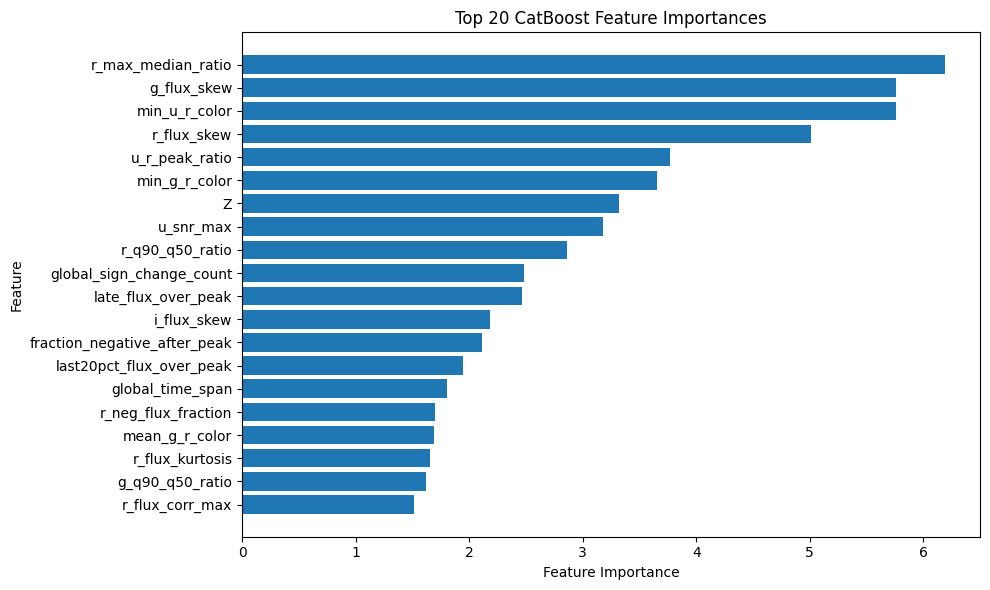

In [11]:

import matplotlib.pyplot as plt

# Get feature importances from the trained final model
importances = final_model.get_feature_importance()

# If X is a pandas DataFrame, use its column names
feature_names = X.columns

# Build DataFrame
feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort descending and keep top 20
top20_feat_imp = feat_imp_df.sort_values(by="importance", ascending=False).head(20)

# Display table
print(top20_feat_imp)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top20_feat_imp["feature"][::-1], top20_feat_imp["importance"][::-1])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 CatBoost Feature Importances")
plt.tight_layout()
plt.show()

In [12]:
'''
Create the final Kaggle submission .csv file. Predict using the testing dataset
'''

test_probs = final_model.predict_proba(X_test)[:, 1]

test_preds = (test_probs >= best_threshold).astype(int)

# Build submission dataframe
submission = pd.DataFrame({
    "object_id": test_features["object_id"],
    "prediction": test_preds
})

# Save file
submission.to_csv("submission_dylan_hammond_V3.csv", index=False)

print("Submission saved.")
print(submission.head())

Submission saved.
                      object_id  prediction
0      Eluwaith_Mithrim_nothrim           0
1            Eru_heledir_archam           0
2             Gonhir_anann_fuin           0
3  Gwathuirim_haradrim_tegilbor           0
4              achas_minai_maen           0
